## STEP 1: Importing important libraries and implementing Exploratory Data Analysis


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

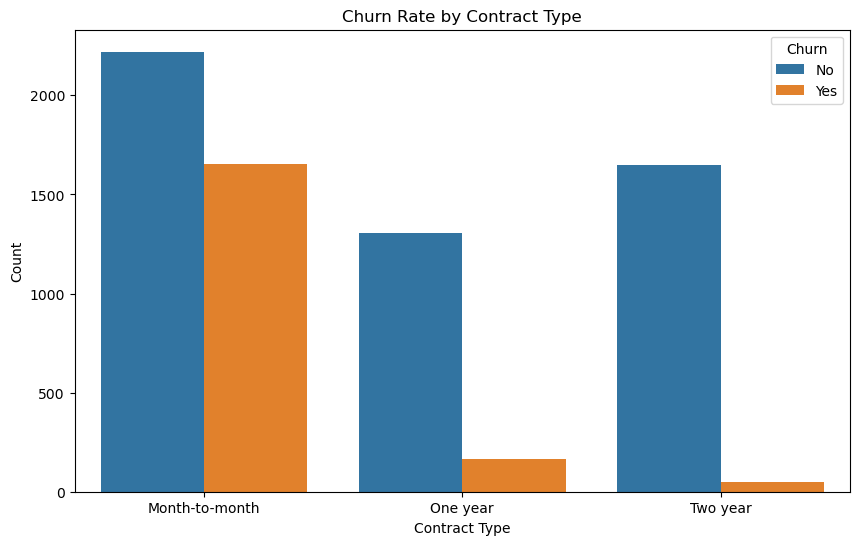

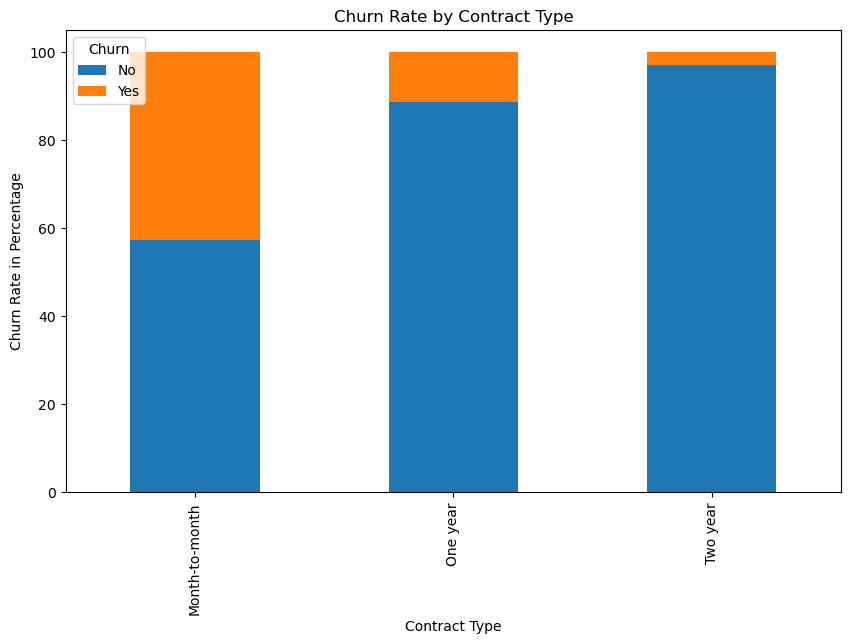

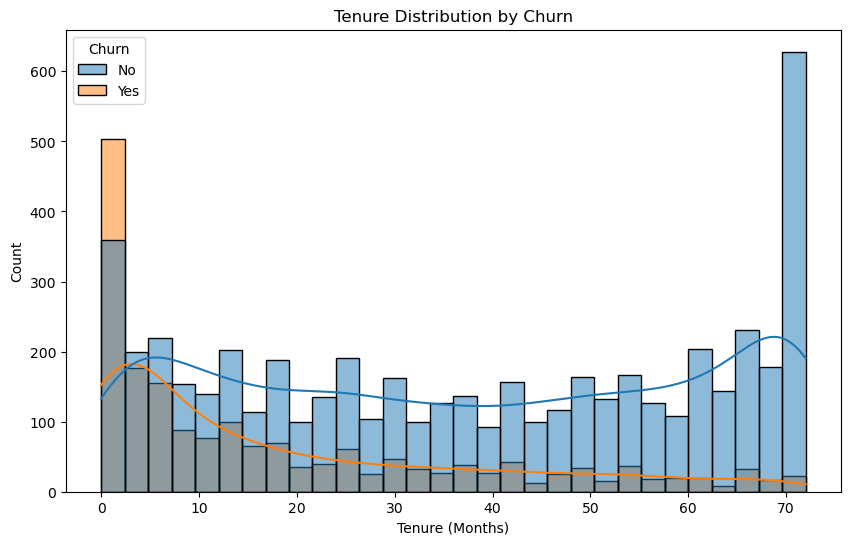

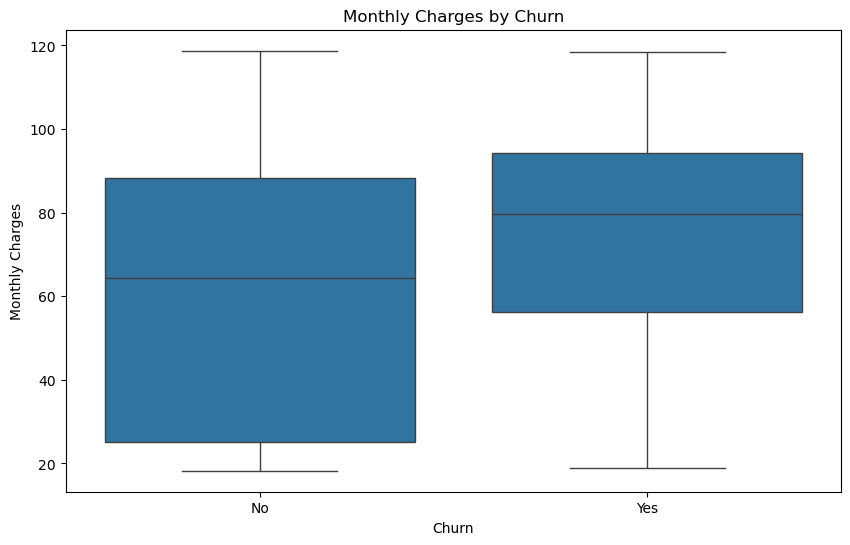

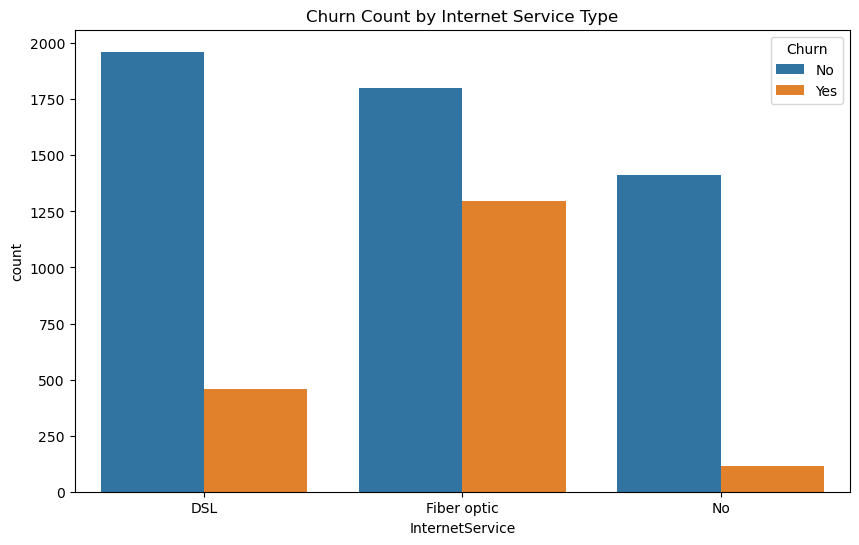

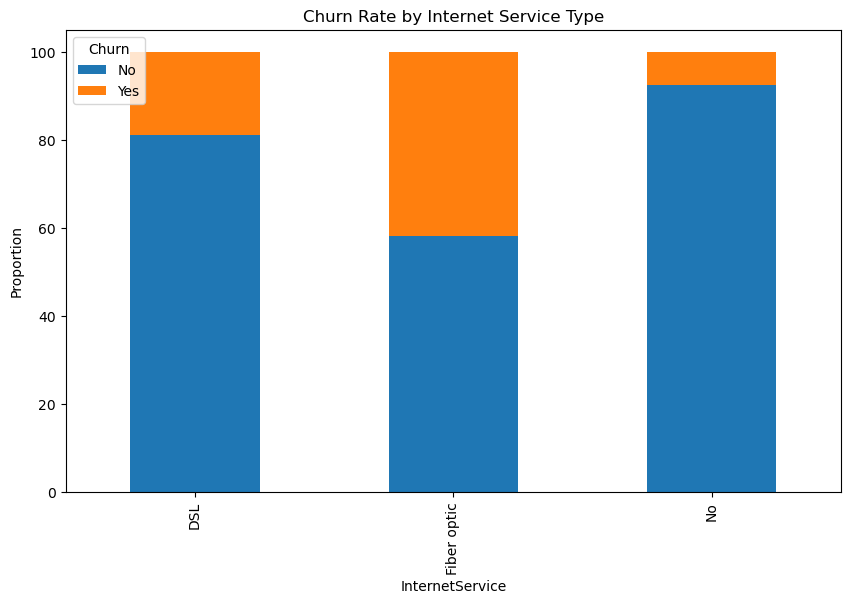

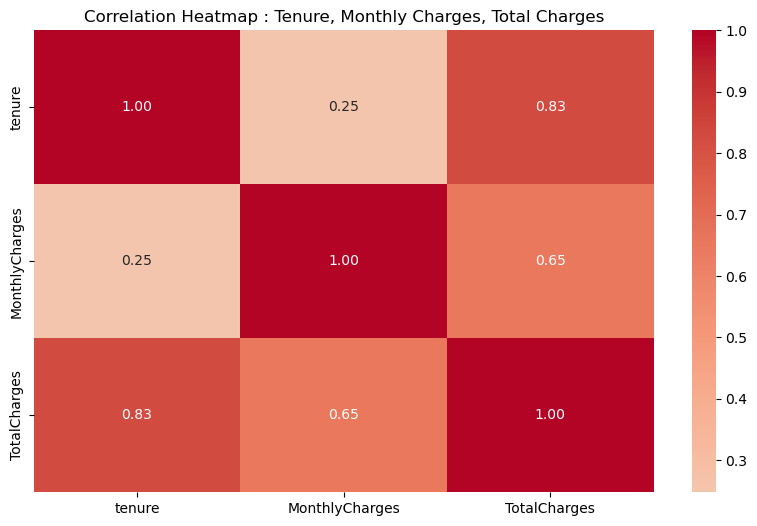

None dropped TotalCharges column
(7043, 20)


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Datamanipulation
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())
print(df.head())
print(df.tail())
df.info() # shows the data types and the statistics of the dataset
df.describe() # shows the statistics of the dataset
df.isnull().sum() # shows the number of missing values in each column
df.columns
print(df.shape)

# convert the data type of TotalCharges column to numeric and handle the whitespaces values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# target distribution
print("Target variable distribution:")
print(df['Churn'].value_counts(normalize=True))

# churn rate by contract type the most important plot
# the counterplt use raw data to show the volume of churners in each contract type
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

# counter plot to show the contract type with the highest churn rate
# normalize by index  divide each row by the sum of that row to get the percentage of churners in each contract type the actual rate
churn_rate = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
churn_rate.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate in Percentage')
plt.legend(title = 'Churn')
plt.show()

# churn rate by tenure histogram of tenure split by churn; new customers are more likely to churn than long-term customers in this dataset
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='layer', bins=30,kde=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()
# new customers are more likely to churn than long-term customers in this dataset an insight for retention strategies.


# monthlyCharges vs Churn box plot; customers with higher monthly charges are more likely to churn in this dataset
#because it directly shows the median and spread for each churn group side by side —
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

# internetservice vs Churn bar plot; customers with fiber optic internet service are more likely to churn in this dataset
#"fiber customers are a higher-risk segment because they tend to be newer, price-sensitive, contract-flexible customers who 
# haven't attached protective services" (implies a retention/bundling strategy — e.g., promote annual contracts and free security add-ons specifically to new fiber signups)
plt.figure(figsize=(10, 6))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn Count by Internet Service Type')
plt.show()

internet_churn_rate = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn_rate.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Churn Rate by Internet Service Type')
plt.ylabel('Proportion')
plt.show()
df.groupby('InternetService')['MonthlyCharges'].mean()
pd.crosstab(df['InternetService'], df['Contract'], normalize='index')

# a heatmap correlation for tenure, monthly charges, and total charges; tenure and total charges are highly correlated, while monthly charges are not strongly correlated with either of the other two variables.
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap : Tenure, Monthly Charges, Total Charges')
plt.show()
# total charges is largely derivable from the other 2 that is tenure and monthly charges, so it may not be necessary to include it in a predictive model.
# Dropping TotalCharges: correlation heatmap shows r=0.83 with tenure,
# indicating strong redundancy. tenure and MonthlyCharges retained as
# they capture largely independent information (r=0.25) and were both
# individually confirmed as churn drivers in EDA above.
print(df.drop(['TotalCharges'], axis=1, inplace=True),"dropped TotalCharges column")
print(df.shape)

## STEP 2: Encoding categorical and Building the baseline model

In [49]:
# one-hot encoding multi-category columns
# encoding the binary categorical yes or no columns to 1  and 0 and gender to 1 an 0 for male and female
if df['gender'].dtype == 'object':
	df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

df.drop(columns=['customerID'], errors='ignore', inplace=True)

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for column in binary_cols:
	if column in df.columns and df[column].dtype == 'object':
		df[column] = df[column].map({'Yes': 1, 'No': 0})

multi_category_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
existing_multi_category_cols = [column for column in multi_category_cols if column in df.columns]
df = pd.get_dummies(df, columns=existing_multi_category_cols, drop_first=True)

print(df.isnull().sum().sum())
print(df['gender'].unique())

# train and test spilt and baseline building ith logigistic regression as the baseline model for churn prediction. The dataset is split into training and testing sets, and a logistic regression model is trained on the training data. The model's performance is then evaluated on the test data using accuracy, precision, recall, and F1-score metrics.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
# Predictions and probabilities for the balanced model
y_pred_balanced = model_balanced.predict(X_test)
y_proba_balanced = model_balanced.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

print("Accuracy (Balanced):", accuracy_score(y_test, y_pred_balanced))

print("Classification Report:")
print(classification_report(y_test, y_pred_balanced))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("ROC AUC Score:", roc_auc_score(y_test,y_proba_balanced))


0
[0 1]
Accuracy: 0.7395315826827538
Accuracy (Balanced): 0.7395315826827538
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409

Confusion Matrix:
[[753 282]
 [ 85 289]]
ROC AUC Score: 0.8386292593453719


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_balanced)

# find threshold that maximizes F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold for F1:", best_threshold)
print("Precision at that threshold:", precisions[best_idx])
print("Recall at that threshold:", recalls[best_idx])
print("F1 at that threshold:", f1_scores[best_idx])

# apply the new threshold
y_pred_tuned = (y_proba_balanced >= best_threshold).astype(int)

print("\nClassification Report at tuned threshold:")
print(classification_report(y_test, y_pred_tuned))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

#threshold tuning added only a small, marginal improvement on top of class 
# weighting — F1 moved from 0.61 to 0.62, recall barely changed (0.77 → 0.76), 
# precision barely changed (0.51 → 0.53). The real gain in this pipeline came from class_weight='balanced',
#  not from the threshold sweep. That's a genuinely useful finding — it tells you where the effort actually paid off, 
# rather than implying every techniquyese contributed equally.

Best threshold for F1: 0.5413082572606743
Precision at that threshold: 0.5250463821892394
Recall at that threshold: 0.7566844919786097
F1 at that threshold: 0.6199342821012154

Classification Report at tuned threshold:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.77      1409

Confusion Matrix:
[[779 256]
 [ 91 283]]


In [53]:
# testing random forest classifier as a more complex model to see if it can improve the performance of the churn prediction model. The random forest classifier is trained on the training data and evaluated on the test data using accuracy, precision, recall, and F1-score metrics.
from sklearn.ensemble import RandomForestClassifier

#max_depth 10 caps how deep each tree can grow, which helps prevent overfitting. n_estimators=200 means the forest will consist of 200 trees, which is a good balance between performance and computational cost. 
# random_state=42 ensures reproducibility of results. 
# class_weight='balanced' tells the model to pay more attention to the minority class (churners) during training, which can help improve the model's ability to correctly identify churners.

rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_rf))
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False).head(10))

Random Forest Results:
Accuracy: 0.7608232789212207
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Confusion Matrix:
[[804 231]
 [106 268]]
ROC AUC Score: 0.8384949236611641
tenure                            0.225072
MonthlyCharges                    0.117943
Contract_Two year                 0.104020
InternetService_Fiber optic       0.077735
PaymentMethod_Electronic check    0.057034
Contract_One year                 0.049770
OnlineSecurity_Yes                0.037958
TechSupport_Yes                   0.032970
PaperlessBilling                  0.023544
OnlineBackup_Yes                  0.020704
dtype: float64


In [54]:
# pick which model to inspect - using balanced logistic regression here
results_df = X_test.copy()
results_df['Actual_Churn'] = y_test.values
results_df['Predicted_Churn'] = y_pred_balanced
results_df['Churn_Probability'] = y_proba_balanced.round(3)

# show a sample of predictions
print(results_df[['Actual_Churn', 'Predicted_Churn', 'Churn_Probability']].sample(10, random_state=1))

      Actual_Churn  Predicted_Churn  Churn_Probability
126              1                1              0.810
4017             0                0              0.197
5860             1                1              0.737
4114             0                0              0.022
3790             1                0              0.201
984              0                0              0.015
4408             0                0              0.040
2923             0                0              0.363
3505             0                1              0.750
4162             0                0              0.029


In [ ]:
#false negatives (missed churners — the costliest error type):
false_negatives = results_df[(results_df['Actual_Churn'] == 1) & (results_df['Predicted_Churn'] == 0)]
print("Missed churners:", len(false_negatives))
print(false_negatives[['tenure', 'MonthlyCharges', 'Churn_Probability']].head(10))

#false positives (false alarms):
false_positives = results_df[(results_df['Actual_Churn'] == 0) & (results_df['Predicted_Churn'] == 1)]
print("False alarms:", len(false_positives))
print(false_positives[['tenure', 'MonthlyCharges', 'Churn_Probability']].head(10))

#the model's errors are concentrated in customers with borderline probabilities near the boundaries of known risk patterns, 
# not in confidently-wrong predictions

Missed churners: 85
      tenure  MonthlyCharges  Churn_Probability
2488      31           55.25              0.421
5086      45           20.40              0.120
3408       4           50.70              0.485
7011       4           60.40              0.416
5968      12           74.05              0.438
1577      17           98.60              0.477
2361       1           45.95              0.497
6388       1           20.40              0.354
402       69           99.45              0.493
3721       2           20.65              0.345
False alarms: 282
      tenure  MonthlyCharges  Churn_Probability
2280       8          100.15              0.867
4460      18           78.20              0.668
5748      21           99.85              0.822
3568      21           99.15              0.720
2136      15           91.00              0.831
1242      21           28.50              0.501
1838      54           90.05              0.693
6979       1           24.20              0.615
25